# Cardiovascular Disease Prediction - Complete Epsilon AI Project


## Project Objectives
- Analyze cardiovascular disease risk factors.
- Perform data cleaning and preprocessing.
- Conduct univariate and bivariate analysis.
- Create new features (Feature Engineering).
- Apply Feature Selection.
- Compare 3 Machine Learning Algorithms.
- Tune the best model using GridSearchCV.
- Evaluate using multiple metrics.
- Save and deploy the model using Streamlit.


In [17]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import streamlit as st

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)


## Load Dataset

In [18]:
df = pd.read_csv(
    r"G:\sayed\Career\data science epsilon ai\M final project ML\cardio_train.csv",
    sep=";"
)
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [19]:
df.drop('id', axis=1, inplace=True)

In [20]:

print('Shape:', df.shape)
df.info()


Shape: (70000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  int64  
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  int64  
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  int64  
 5   ap_lo        70000 non-null  int64  
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 6.4 MB


## Data Cleaning

In [21]:

print(df.isnull().sum())


age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


In [22]:

df['age_years'] = (df['age']/365).astype(int)

df['BMI'] = df['weight'] / ((df['height']/100)**2)

df['Age_Group'] = pd.cut(
    df['age_years'],
    bins=[0,40,50,60,100],
    labels=['Young','Middle','Senior','Old']
)

df = df[(df['ap_hi'] > 0)]
df = df[(df['ap_lo'] > 0)]
df = df[(df['ap_hi'] < 250)]
df = df[(df['ap_lo'] < 200)]
df = df[df['ap_hi'] > df['ap_lo']]

df.shape


(68709, 15)

In [23]:
# Statistical Measures About the Data

summary_stats = df.describe().T
summary_stats["Missing Values"] = df.isnull().sum()

display(summary_stats)

feature_info = pd.DataFrame({
    'Feature': [
        'id', 'age', 'gender', 'height', 'weight',
        'ap_hi', 'ap_lo', 'cholesterol',
        'gluc', 'smoke', 'alco', 'active', 'cardio'
    ],
    'Description': [
        'Patient ID Number',
        'Age (in days)',
        'Gender (1 = Women, 2 = Men)',
        'Height (cm)',
        'Weight (kg)',
        'Systolic Blood Pressure',
        'Diastolic Blood Pressure',
        'Cholesterol (1=Normal, 2=Above Normal, 3=Well Above Normal)',
        'Glucose (1=Normal, 2=Above Normal, 3=Well Above Normal)',
        'Smoking Status (0=No, 1=Yes)',
        'Alcohol Consumption (0=No, 1=Yes)',
        'Physical Activity (0=No, 1=Yes)',
        'Cardiovascular Disease (0=No Disease, 1=Disease)'
    ]
})

display(feature_info)

,count,mean,std,min,25%,50%,75%,max,Missing Values
age,68709.0,19464.274826,2468.110540,10798.000000,17657.000000,19701.000000,21324.000000,23713.000000,0
gender,68709.0,1.348601,0.476531,1.000000,1.000000,1.000000,2.000000,2.000000,0
height,68709.0,164.359502,8.191113,55.000000,159.000000,165.000000,170.000000,250.000000,0
weight,68709.0,74.116804,14.331936,11.000000,65.000000,72.000000,82.000000,200.000000,0
ap_hi,68709.0,126.670072,16.707956,16.000000,120.000000,120.000000,140.000000,240.000000,0
ap_lo,68709.0,81.272570,9.572289,1.000000,80.000000,80.000000,90.000000,182.000000,0
cholesterol,68709.0,1.364654,0.678908,1.000000,1.000000,1.000000,2.000000,3.000000,0
gluc,68709.0,1.225633,0.571476,1.000000,1.000000,1.000000,1.000000,3.000000,0
smoke,68709.0,0.087922,0.283183,0.000000,0.000000,0.000000,0.000000,1.000000,0
alco,68709.0,0.053341,0.224714,0.000000,0.000000,0.000000,0.000000,1.000000,0


,Feature,Description
0,id,Patient ID Number
1,age,Age (in days)
2,gender,"Gender (1 = Women, 2 = Men)"
3,height,Height (cm)
4,weight,Weight (kg)
5,ap_hi,Systolic Blood Pressure
6,ap_lo,Diastolic Blood Pressure
7,cholesterol,"Cholesterol (1=Normal, 2=Above Normal, 3=Well ..."
8,gluc,"Glucose (1=Normal, 2=Above Normal, 3=Well Abov..."
9,smoke,"Smoking Status (0=No, 1=Yes)"


## Exploratory Data Analysis

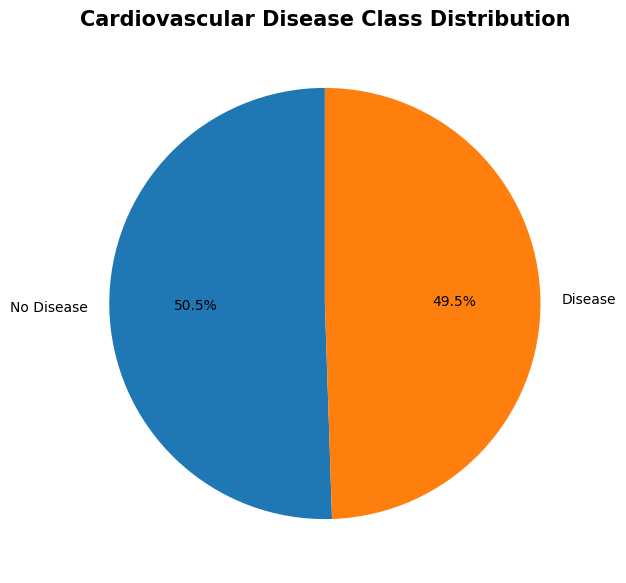

In [24]:
cardio_counts = df['cardio'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    cardio_counts.values,
    labels=['No Disease', 'Disease'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title(
    'Cardiovascular Disease Class Distribution',
    fontsize=15,
    fontweight='bold'
)

plt.show()

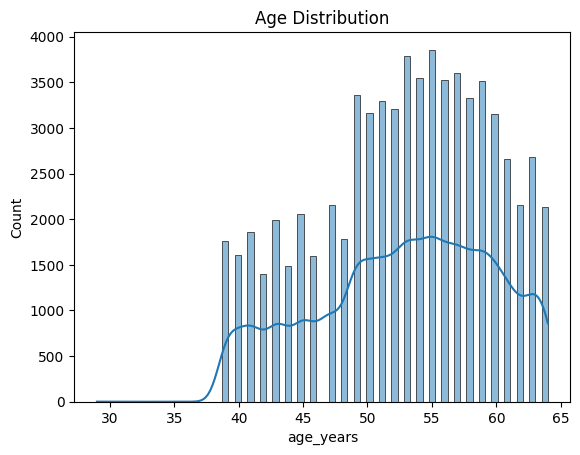

In [25]:
sns.histplot(df['age_years'], kde=True); plt.title('Age Distribution'); plt.show()

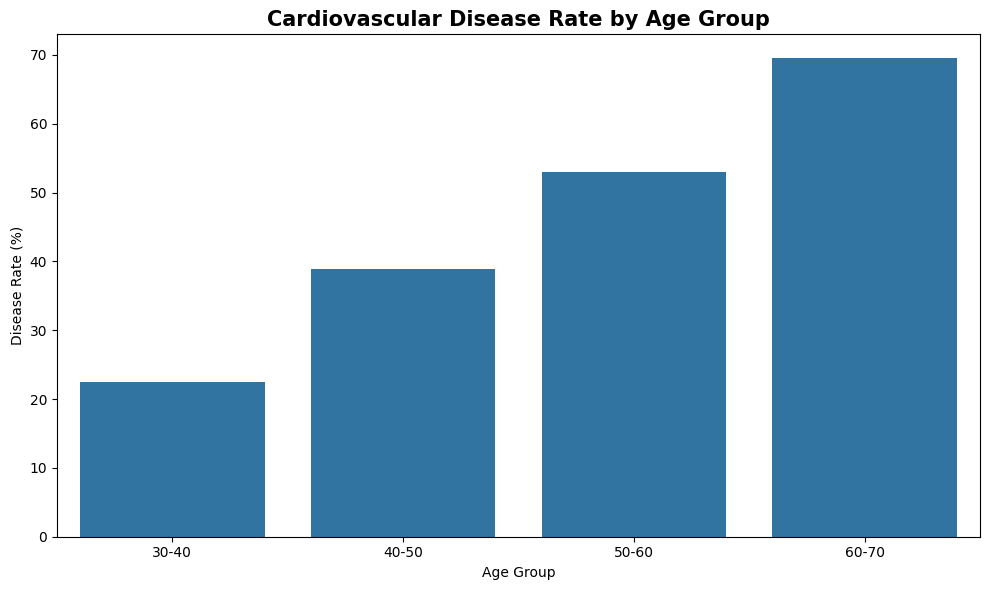

In [26]:
df['age_group'] = pd.cut(
    df['age_years'],
    bins=[30,40,50,60,70],
    labels=['30-40','40-50','50-60','60-70']
)

age_cardio = (
    pd.crosstab(
        df['age_group'],
        df['cardio'],
        normalize='index'
    )[1] * 100
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=age_cardio.index,
    y=age_cardio.values
)

plt.title(
    'Cardiovascular Disease Rate by Age Group',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Age Group')
plt.ylabel('Disease Rate (%)')

plt.tight_layout()
plt.show()

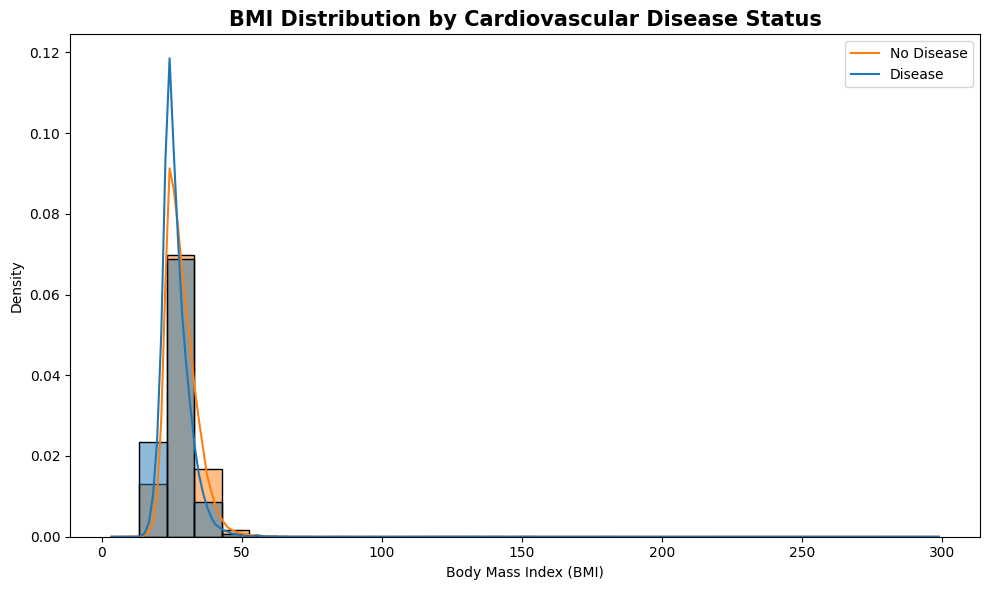

In [27]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='BMI',
    hue='cardio',
    kde=True,
    bins=30,
    stat='density',
    common_norm=False
)

plt.title(
    'BMI Distribution by Cardiovascular Disease Status',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Density')

plt.legend(
    labels=['No Disease', 'Disease']
)

plt.tight_layout()
plt.show()

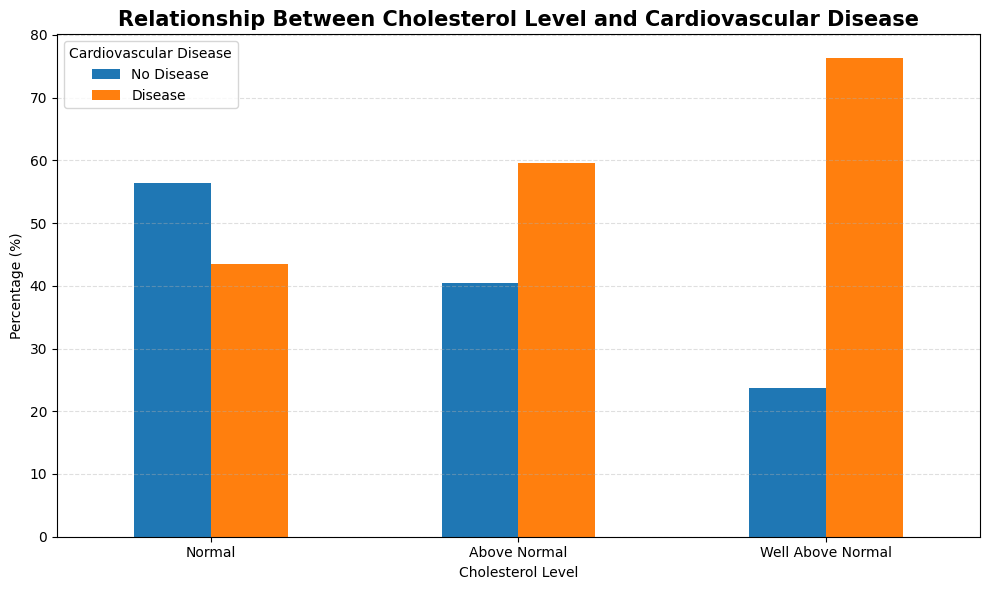

In [28]:
# Cholesterol Level vs Cardiovascular Disease (%)

chol_cardio = pd.crosstab(
    df['cholesterol'],
    df['cardio'],
    normalize='index'
) * 100

chol_cardio.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title(
    'Relationship Between Cholesterol Level and Cardiovascular Disease',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Cholesterol Level')
plt.ylabel('Percentage (%)')

plt.xticks(
    [0,1,2],
    ['Normal', 'Above Normal', 'Well Above Normal'],
    rotation=0
)

plt.legend(
    ['No Disease', 'Disease'],
    title='Cardiovascular Disease'
)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

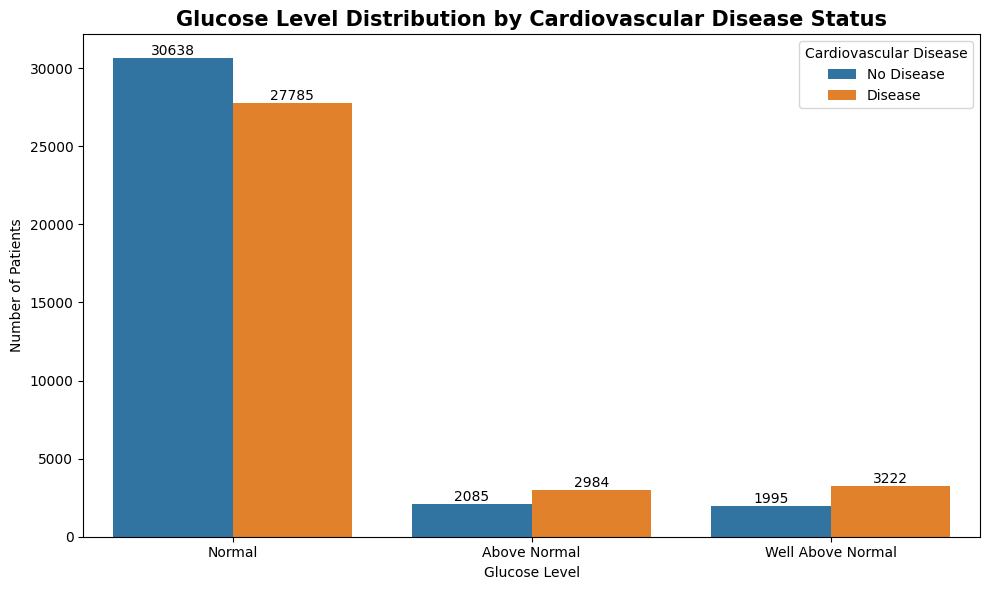

In [29]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df,
    x='gluc',
    hue='cardio'
)

plt.title(
    'Glucose Level Distribution by Cardiovascular Disease Status',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Glucose Level')
plt.ylabel('Number of Patients')

plt.xticks(
    [0,1,2],
    ['Normal', 'Above Normal', 'Well Above Normal']
)

plt.legend(
    title='Cardiovascular Disease',
    labels=['No Disease', 'Disease']
)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

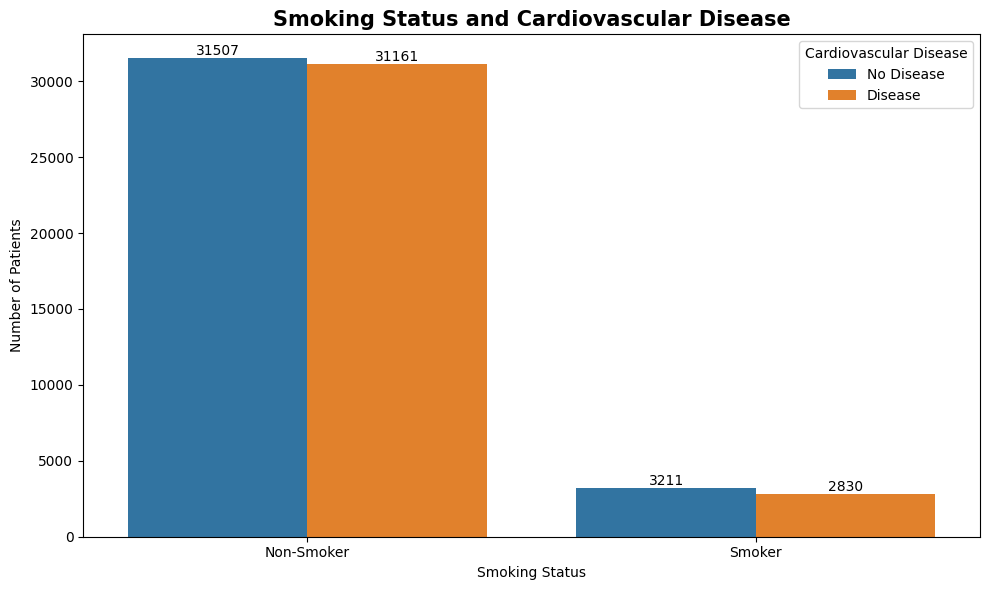

In [30]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df,
    x='smoke',
    hue='cardio'
)

plt.title(
    'Smoking Status and Cardiovascular Disease',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Smoking Status')
plt.ylabel('Number of Patients')

plt.xticks(
    [0,1],
    ['Non-Smoker', 'Smoker']
)

plt.legend(
    title='Cardiovascular Disease',
    labels=['No Disease', 'Disease']
)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

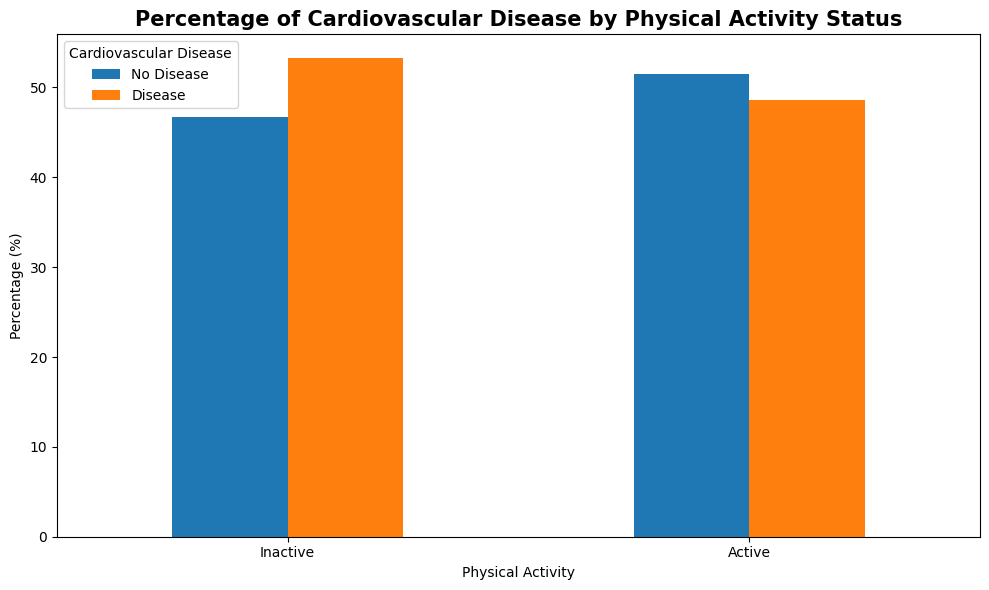

cardio,0,1
active,,
0,46.8,53.2
1,51.5,48.5


In [31]:
activity_cardio = pd.crosstab(
    df['active'],
    df['cardio'],
    normalize='index'
) * 100

activity_cardio.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title(
    'Percentage of Cardiovascular Disease by Physical Activity Status',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Physical Activity')
plt.ylabel('Percentage (%)')

plt.xticks(
    [0,1],
    ['Inactive', 'Active'],
    rotation=0
)

plt.legend(
    ['No Disease', 'Disease'],
    title='Cardiovascular Disease'
)

plt.tight_layout()
plt.show()
pd.crosstab(
    df['active'],
    df['cardio'],
    normalize='index'
).round(3) * 100

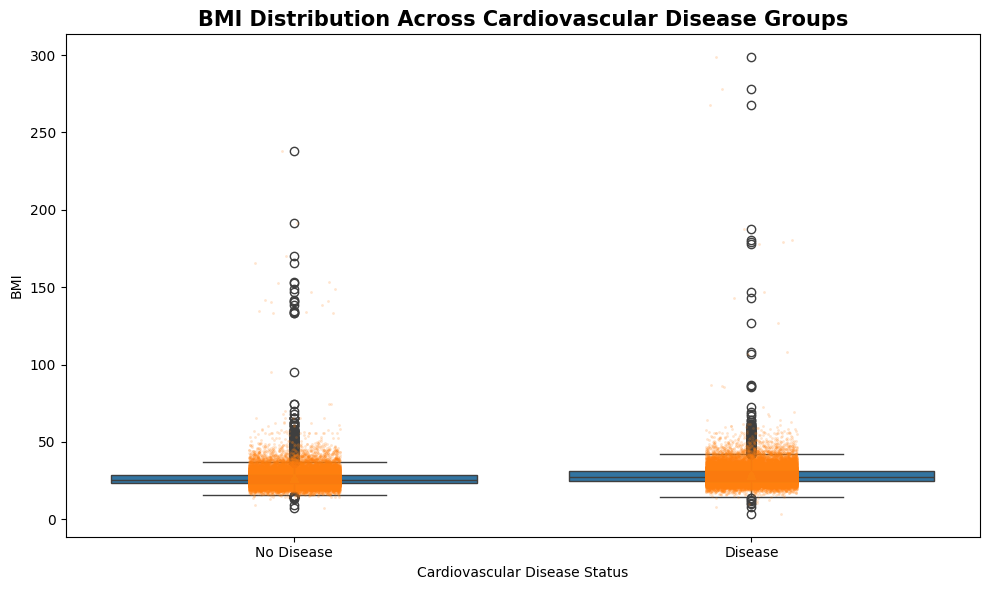

             mean     median       min         max
cardio                                            
0       26.540334  25.469828  7.022248  237.768633
1       28.526284  27.434842  3.471784  298.666667


In [32]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='cardio',
    y='BMI',
    data=df,
    showmeans=True
)

sns.stripplot(
    x='cardio',
    y='BMI',
    data=df,
    alpha=0.2,
    size=2
)

plt.title(
    'BMI Distribution Across Cardiovascular Disease Groups',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Cardiovascular Disease Status')
plt.ylabel('BMI')

plt.xticks(
    [0,1],
    ['No Disease', 'Disease']
)

plt.tight_layout()
plt.show()
print(df.groupby('cardio')['BMI'].agg(['mean','median','min','max']))

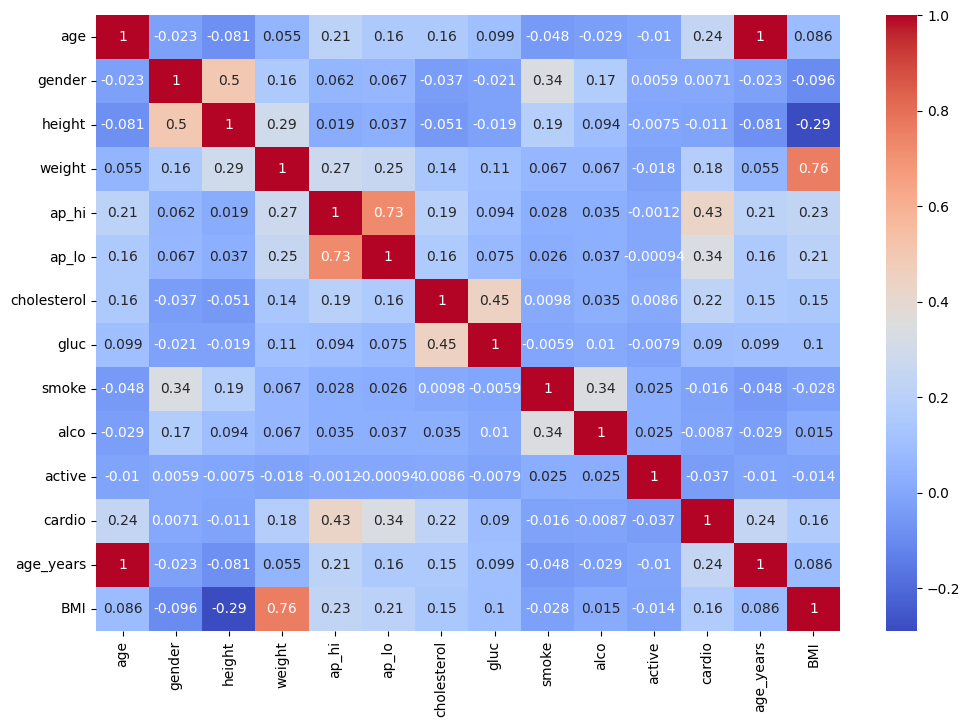

In [33]:
plt.figure(figsize=(12,8)); sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm'); plt.show()

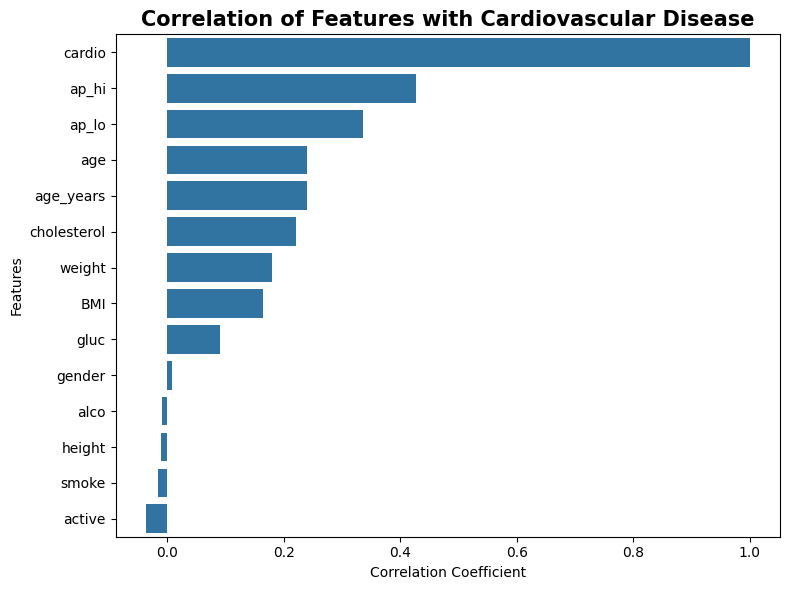

In [34]:
cardio_corr = (
    df.corr(numeric_only=True)['cardio']
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,6))

sns.barplot(
    x=cardio_corr.values,
    y=cardio_corr.index
)

plt.title(
    'Correlation of Features with Cardiovascular Disease',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

## Feature Selection (Filter Method)

In [35]:
df.isnull().sum()

age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
age_years      0
BMI            0
Age_Group      0
age_group      4
dtype: int64

In [36]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

X = df.drop(
    ['cardio', 'Age_Group', 'age_group'],
    axis=1,
    errors='ignore'
)

y = df['cardio']

selector = SelectKBest(
    score_func=mutual_info_classif,
    k=10
)

selector.fit(X, y)

selected_features = X.columns[
    selector.get_support()
]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['age', 'gender', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc',
       'active', 'age_years', 'BMI'],
      dtype='object')


## Train Test Split

In [37]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



## Model 1 - Logistic Regression

In [38]:

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
lr_pred = lr.predict(X_test)


## Model 2 - Decision Tree

In [39]:

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
dt_pred = dt.predict(X_test)


## Model 3 - Random Forest

In [40]:

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)
rf_pred = rf.predict(X_test)


## Compare Models

In [41]:

results = pd.DataFrame({
    'Model':['Logistic Regression','Decision Tree','Random Forest'],
    'Precision':[
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall':[
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1':[
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

results.sort_values('F1', ascending=False)


,Model,Precision,Recall,F1
0,Logistic Regression,0.756041,0.671962,0.711526
2,Random Forest,0.718486,0.700941,0.709605
1,Decision Tree,0.633388,0.623419,0.628364


In [42]:
results = pd.DataFrame({
    'Model':['Logistic Regression','Decision Tree','Random Forest'],
    'Accuracy':[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision':[
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall':[
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1 Score':[
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

results.sort_values('F1 Score', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.730461,0.756041,0.671962,0.711526
2,Random Forest,0.716199,0.718486,0.700941,0.709605
1,Decision Tree,0.635206,0.633388,0.623419,0.628364


## Hyperparameter Tuning

In [43]:

param_grid = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='recall'
)

grid.fit(X_train,y_train)

best_model = grid.best_estimator_
print(grid.best_params_)


{'max_depth': None, 'n_estimators': 200}


## Final Evaluation

In [44]:

pred = best_model.predict(X_test)

print('Accuracy:', accuracy_score(y_test,pred))
print('Precision:', precision_score(y_test,pred))
print('Recall:', recall_score(y_test,pred))
print('F1 Score:', f1_score(y_test,pred))

print(classification_report(y_test,pred))


Accuracy: 0.7160529762771067
Precision: 0.7172869147659063
Recall: 0.7031479847013827
F1 Score: 0.7101470806715199
              precision    recall  f1-score   support

           0       0.71      0.73      0.72      6944
           1       0.72      0.70      0.71      6798

    accuracy                           0.72     13742
   macro avg       0.72      0.72      0.72     13742
weighted avg       0.72      0.72      0.72     13742



## Confusion Matrix

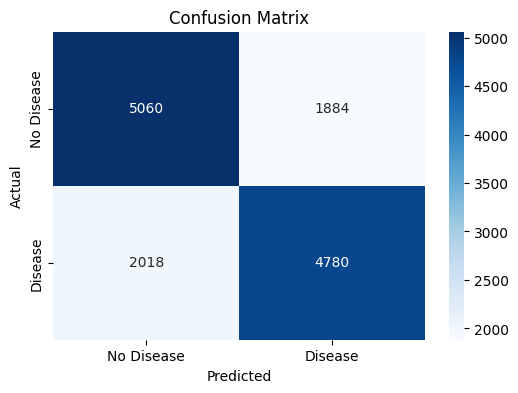

In [45]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Disease', 'Disease'],
    yticklabels=['No Disease', 'Disease']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## ROC Curve

ROC AUC Score: 0.7786


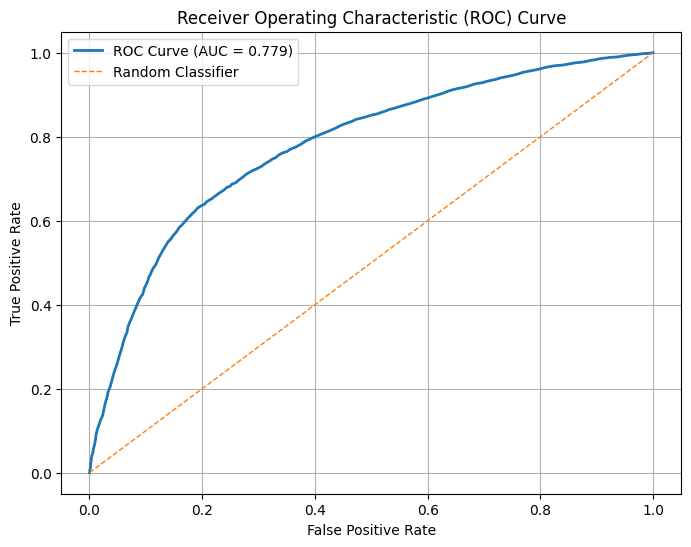

In [46]:
from sklearn.metrics import roc_curve, roc_auc_score

prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, prob)

auc_score = roc_auc_score(y_test, prob)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'ROC Curve (AUC = {auc_score:.3f})'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    linewidth=1,
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)

print(f"ROC AUC Score: {auc_score:.4f}")

plt.show()

## Feature Importance

,Feature,Importance
0,age,0.203084
4,ap_hi,0.159108
12,BMI,0.152461
3,weight,0.113605
2,height,0.108093
5,ap_lo,0.086258
11,age_years,0.075441
6,cholesterol,0.037949
1,gender,0.017174
7,gluc,0.016626


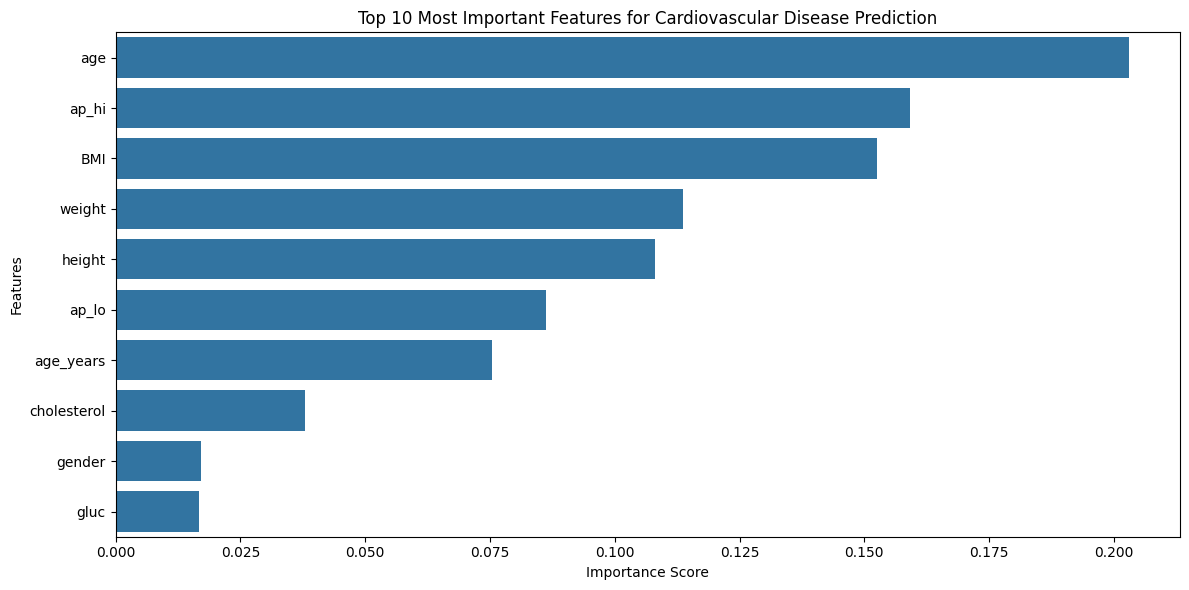

In [47]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

# Sort features by importance
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

# Display Top 10 Features
top_features = importance.head(10)

display(top_features)

# Visualization
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Most Important Features for Cardiovascular Disease Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

In [48]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# PAGE CONFIG
# ======================

st.set_page_config(
    page_title="Cardiovascular Disease Prediction",
    page_icon="❤️",
    layout="wide"
)

# ======================
# LOAD DATA
# ======================

df = pd.read_csv("cardio_train.csv", sep=";")

df["age_years"] = (df["age"] / 365).astype(int)
df["BMI"] = df["weight"] / ((df["height"]/100)**2)

df["age_group"] = pd.cut(
    df["age_years"],
    bins=[30,40,50,60,70],
    labels=["30-40","40-50","50-60","60-70"]
)

# ======================
# LOAD MODEL
# ======================

try:
    model = joblib.load("cardio_model.pkl")
    scaler = joblib.load("scaler.pkl")
    feature_columns = joblib.load("feature_columns.pkl")
except:
    model = None

# ======================
# SIDEBAR
# ======================

st.sidebar.title("❤️ Navigation")

page = st.sidebar.radio(
    "Select Page",
    [
        "Overview",
        "EDA Dashboard",
        "Model Performance",
        "Prediction"
    ]
)

# ======================
# FILTERS
# ======================

st.sidebar.markdown("---")
st.sidebar.subheader("Filters")

gender_filter = st.sidebar.multiselect(
    "Gender",
    sorted(df["gender"].unique()),
    default=sorted(df["gender"].unique())
)

chol_filter = st.sidebar.multiselect(
    "Cholesterol",
    sorted(df["cholesterol"].unique()),
    default=sorted(df["cholesterol"].unique())
)

cardio_filter = st.sidebar.multiselect(
    "Disease Status",
    sorted(df["cardio"].unique()),
    default=sorted(df["cardio"].unique())
)

filtered_df = df[
    (df["gender"].isin(gender_filter))
    &
    (df["cholesterol"].isin(chol_filter))
    &
    (df["cardio"].isin(cardio_filter))
]

# ======================
# OVERVIEW PAGE
# ======================

if page == "Overview":

    st.title("❤️ Cardiovascular Disease Prediction Dashboard")

    c1,c2,c3,c4 = st.columns(4)

    c1.metric(
        "Patients",
        len(filtered_df)
    )

    c2.metric(
        "Average Age",
        round(filtered_df["age_years"].mean(),1)
    )

    c3.metric(
        "Average BMI",
        round(filtered_df["BMI"].mean(),1)
    )

    c4.metric(
        "Disease Rate",
        f"{filtered_df['cardio'].mean()*100:.1f}%"
    )

    st.markdown("---")

    st.subheader("Dataset Preview")

    st.dataframe(filtered_df.head())

    st.subheader("Statistical Summary")

    st.dataframe(filtered_df.describe())

# ======================
# EDA PAGE
# ======================

elif page == "EDA Dashboard":

    st.title("📊 Exploratory Data Analysis")

    fig1 = px.histogram(
        filtered_df,
        x="age_years",
        nbins=30,
        title="Age Distribution"
    )

    st.plotly_chart(
        fig1,
        use_container_width=True
    )

    fig2 = px.histogram(
        filtered_df,
        x="BMI",
        color="cardio",
        title="BMI Distribution"
    )

    st.plotly_chart(
        fig2,
        use_container_width=True
    )

    age_cardio = pd.crosstab(
        filtered_df["age_group"],
        filtered_df["cardio"],
        normalize="index"
    ) * 100

    st.subheader(
        "Disease Rate by Age Group"
    )

    st.bar_chart(age_cardio)

    st.subheader(
        "Correlation Heatmap"
    )

    corr = filtered_df.corr(
        numeric_only=True
    )

    fig = px.imshow(
        corr,
        text_auto=True,
        aspect="auto"
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

# ======================
# MODEL PAGE
# ======================

elif page == "Model Performance":

    st.title("🤖 Model Performance")

    try:

        importance = pd.DataFrame({
            "Feature": feature_columns,
            "Importance": model.feature_importances_
        })

        importance = importance.sort_values(
            "Importance",
            ascending=False
        )

        st.subheader(
            "Top Important Features"
        )

        fig = px.bar(
            importance.head(10),
            x="Importance",
            y="Feature",
            orientation="h"
        )

        st.plotly_chart(
            fig,
            use_container_width=True
        )

    except:
        st.warning(
            "Feature Importance Not Available"
        )

# ======================
# PREDICTION PAGE
# ======================

elif page == "Prediction":

    st.title(
        "🩺 Predict Cardiovascular Disease"
    )

    age = st.number_input(
        "Age",
        30,
        80,
        50
    )

    gender = st.selectbox(
        "Gender",
        [1,2]
    )

    height = st.number_input(
        "Height (cm)",
        100,
        250,
        170
    )

    weight = st.number_input(
        "Weight (kg)",
        30,
        200,
        75
    )

    ap_hi = st.number_input(
        "Systolic BP",
        80,
        250,
        120
    )

    ap_lo = st.number_input(
        "Diastolic BP",
        40,
        200,
        80
    )

    cholesterol = st.selectbox(
        "Cholesterol",
        [1,2,3]
    )

    gluc = st.selectbox(
        "Glucose",
        [1,2,3]
    )

    smoke = st.selectbox(
        "Smoke",
        [0,1]
    )

    alco = st.selectbox(
        "Alcohol",
        [0,1]
    )

    active = st.selectbox(
        "Active",
        [0,1]
    )

    bmi = weight / ((height/100)**2)

    st.info(
        f"BMI = {bmi:.2f}"
    )

    if st.button(
        "Predict Disease"
    ):

        if model is None:

            st.error(
                "Model files not found."
            )

        else:

            patient = pd.DataFrame({
                "id":[0],
                "age":[age*365],
                "gender":[gender],
                "height":[height],
                "weight":[weight],
                "ap_hi":[ap_hi],
                "ap_lo":[ap_lo],
                "cholesterol":[cholesterol],
                "gluc":[gluc],
                "smoke":[smoke],
                "alco":[alco],
                "active":[active],
                "age_years":[age],
                "BMI":[bmi]
            })

            patient = patient[feature_columns]

            patient_scaled = scaler.transform(
                patient
            )

            prediction = model.predict(
                patient_scaled
            )[0]

            probability = model.predict_proba(
                patient_scaled
            )[0][1]

            if prediction == 1:

                st.error(
                    f"High Risk ({probability:.1%})"
                )

            else:

                st.success(
                    f"Low Risk ({1-probability:.1%})"
                )

Overwriting app.py


In [49]:
import os

print(os.getcwd())
print(os.listdir())

g:\sayed\Career\data science epsilon ai\M final project ML\cvd repo
['.git', 'app.py', 'Cardio_Disease_Professional_Final.ipynb', 'cardio_train.csv', 'requirements.txt']


In [ ]:
!streamlit run app.py

## Validation Explanation


Validation is the process of testing the model on unseen data to ensure that it generalizes well and does not overfit the training data.


## Save Model

In [ ]:

joblib.dump(best_model,'cardio_model.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(list(X.columns),'feature_columns.pkl')


['feature_columns.pkl']